In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

csv_path = Path(r"C:\Users\glint\Downloads\archive\amz_uk_price_prediction_dataset.csv")
print(csv_path)

C:\Users\glint\Downloads\archive\amz_uk_price_prediction_dataset.csv


In [20]:
df = pd.read_csv(csv_path)

In [21]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### **Part 1:** Analyzing Best-Seller Trends Across Product Categories
Objective: Understand the relationship between product categories and their best-seller status.

**Crosstab Analysis:**

- Create a crosstab between the product category and the isBestSeller status.
- Are there categories where being a best-seller is more prevalent?

Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.

**Statistical Tests:**

- Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
- Compute Cramér's V to understand the strength of association between best-seller status and category.

**Visualizations:**

- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [22]:
# Generating a crosstab for 'category' and 'isBestSeller'
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])

crosstab_result.sort_values(by=True, ascending=False)

isBestSeller,False,True
category,,
Grocery,9008,556
Health & Personal Care,9017,552
Baby,14709,341
Sports & Outdoors,835935,330
Power & Hand Tools,8353,306
...,...,...
Downhill Ski Boots,1284,0
Digital Frames,774,0
Motorbike Chassis,107,0


In [8]:
crosstab_result.shape[0]

296

In [23]:
crosstab_percent = (crosstab_result.div(crosstab_result.sum(axis=1), axis=0) * 100).round()
crosstab_percent.sort_values(by=True, ascending=False)
# sum(axis=1) → total items per category
# div(..., axis=0) → divides each row by its total
# * 100 → converts to percentage

isBestSeller,False,True
category,,
Smart Home Security & Lighting,94.0,6.0
Health & Personal Care,94.0,6.0
Grocery,94.0,6.0
Power & Hand Tools,96.0,4.0
Mobile Phone Accessories,96.0,4.0
...,...,...
Hi-Fi & Home Audio Accessories,100.0,0.0
Hi-Fi Receivers & Separates,100.0,0.0
Hi-Fi Speakers,100.0,0.0


In [ ]:
# Generating a crosstab for 'category' and 'isBestSeller'
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])

crosstab_result.sort_values(by=True, ascending=False)

isBestSeller,False,True
category,,
Grocery,9008,556
Health & Personal Care,9017,552
Baby,14709,341
Sports & Outdoors,835935,330
Power & Hand Tools,8353,306
...,...,...
Downhill Ski Boots,1284,0
Digital Frames,774,0
Motorbike Chassis,107,0


### Chi-square Tests
Tests the independence of two categorical variables by comparing observed frequencies to expected frequencies.

- The chi-square test is a statistical test used to **determine whether there is a significant association between two categorical variables**. 
- Interpretation: if p-value < 0.05, this suggests that there is a significant association between the categorical variables. P-value >= 0.05, indicates that there is not enough evidence to conclude a significant association between the variables. 

In [ ]:
# - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab_result)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# The p-value ≈ 0 (effectively < 0.001) >> This is far below 0.05
# Best-seller status is NOT independent of product category
# Degrees of freedom = 295>> many categories
# A Chi-square test of independence was conducted to examine the relationship between product category and best-seller status. 
# The test was statistically significant (χ²(295) = 36,540.20, p < 0.001), indicating that best-seller status is strongly associated with product category. 
# Therefore, the distribution of best-sellers varies significantly across categories.

Chi-square statistic: 36540.20270061387
p-value: 0.0
Degrees of freedom: 295


### Cramér's V

While the Chi-square test informs us about the independence of two categorical variables, Cramér's V measures the strength of the association between them. 

- Cramer's V is a measure of association used to **quantify the strength of the relationship between categorical variables**. 
- Interpretation: Cramer's V ranges from 0 to 1, where **0 indicates no association, and 1 represents a perfect association between the variables**. '
A higher value of Cramer's V indicates a stronger relationship between the categorical variables.

In [ ]:
# - Compute Cramér's V to understand the strength of association between best-seller status and category.
import numpy as np

n = crosstab_result.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(crosstab_result.shape)-1)))

print("Cramér's V:", cramers_v)
# Product category does influence best-seller status, but the effect is weak.
# Although the Chi-square test indicates a statistically significant association between product category and best-seller status (p < 0.001), the effect size is small (Cramér’s V = 0.12). 
# This suggests that while category has some influence, it is not a strong predictor of whether a product becomes a best-seller.

Cramér's V: 0.1222829439760564


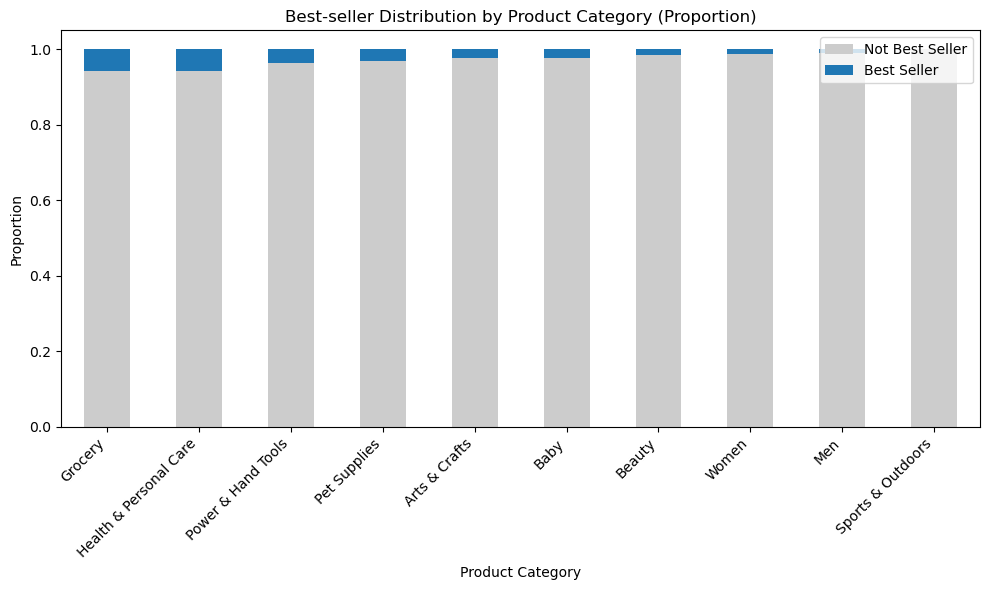

In [ ]:
# Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

# Rename columns for clarity
crosstab_result.columns = ['Not Best Seller', 'Best Seller']

# Keep top categories for readability
top_categories = crosstab_result.sort_values(by='Best Seller', ascending=False).head(10)

# Normalize to proportions (important for comparison)
top_categories_pct = top_categories.div(top_categories.sum(axis=1), axis=0) #axis=1 = sum across columns
#.div(..., axis=0) Divides each row by its own total, axis=0 = align division row-wise
top_categories_pct = top_categories_pct.sort_values(by='Best Seller', ascending=False) 

# Plot stacked bar chart
top_categories_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#cccccc', '#1f77b4']
)

plt.title('Best-seller Distribution by Product Category (Proportion)')
plt.xlabel('Product Category')
plt.ylabel('Proportion')
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### **Part 2:** Exploring Product Prices and Ratings Across Categories and Brands
Objective: Investigate how different product categories influence product prices.

- Preliminary Step: Remove outliers in product prices.

- For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

**Violin Plots:**

- Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
- Which product category tends to have the highest median price? Don't filter here by top categories.

**Bar Charts:**

- Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
- Which product category commands the highest average price? Don't filter here by top categories.

**Box Plots:**

- Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
- Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [43]:
#Function to detect outliers (Tukey’s method)
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    return outliers, lower_bound, upper_bound

data_series = df["price"]
outliers = tukeys_test_outliers(data_series)
print(outliers)

(10         139.00
19         164.99
25         149.99
28         289.00
31         199.99
            ...  
2443619    166.99
2443627    152.58
2443638    108.77
2443641    166.99
2443643    158.99
Name: price, Length: 327688, dtype: float64, np.float64(-44.01), np.float64(99.99000000000001))


In [44]:
outliers, lower_bound, upper_bound = tukeys_test_outliers(df["price"])

df_clean = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

print("Original size:", df.shape)
print("Cleaned size:", df_clean.shape)
print("Outliers removed:", len(outliers))

Original size: (2443651, 9)
Cleaned size: (2115963, 9)
Outliers removed: 327688


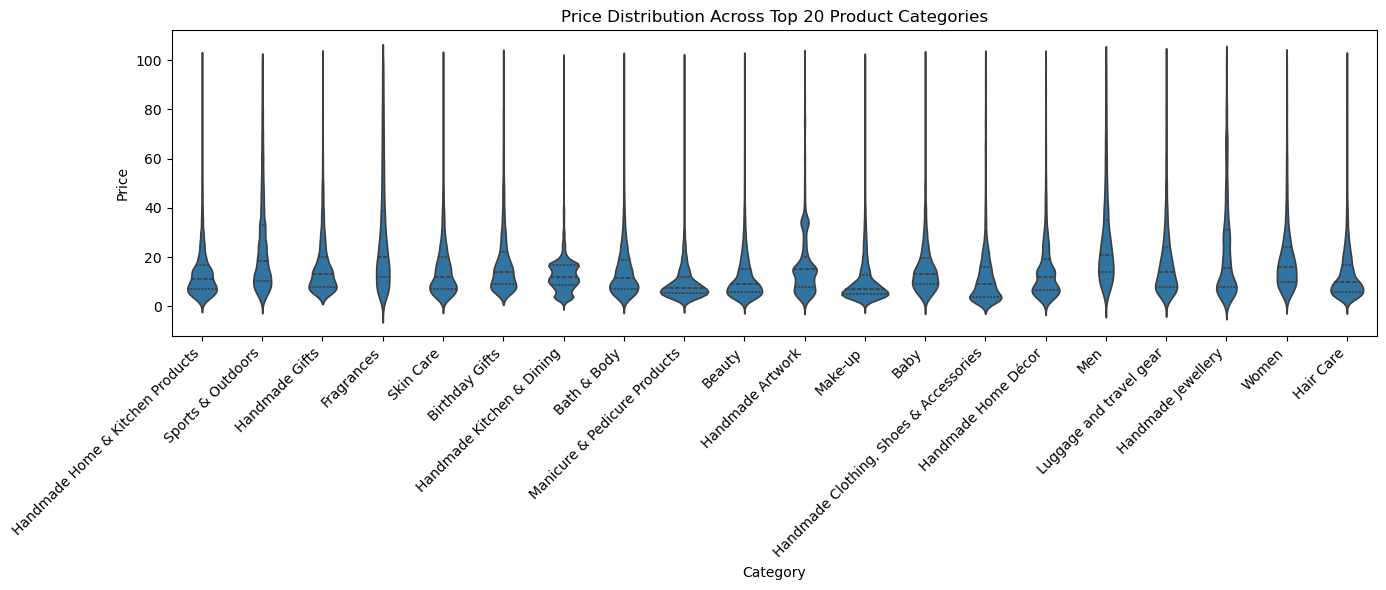

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 20 categories by count
top_categories = df_clean['category'].value_counts().nlargest(20).index

df_top = df_clean[df_clean['category'].isin(top_categories)]

# Plot
plt.figure(figsize=(14,6))
sns.violinplot(
    data=df_top,
    x='category',
    y='price',
    inner='quartile'  # shows median + quartiles
)

plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution Across Top 20 Product Categories')
plt.xlabel('Category')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

In [ ]:
# Median price per category
median_prices = df_clean.groupby('category')['price'].median()

# Get category with highest median
top_category = median_prices.idxmax()
top_value = median_prices.max()

print("Category with highest median price:", top_category)
print("Median price:", top_value)

#A violin plot was used to visualize the distribution of prices across the top 20 product categories, revealing substantial variability in price distributions. 
# When considering all categories, the category with the highest median price is Desktop PCs, with a median price of £74.

Category with highest median price: Desktop PCs
Median price: 74.0


C:\Users\glint\AppData\Local\Temp\ipykernel_9724\1499520600.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


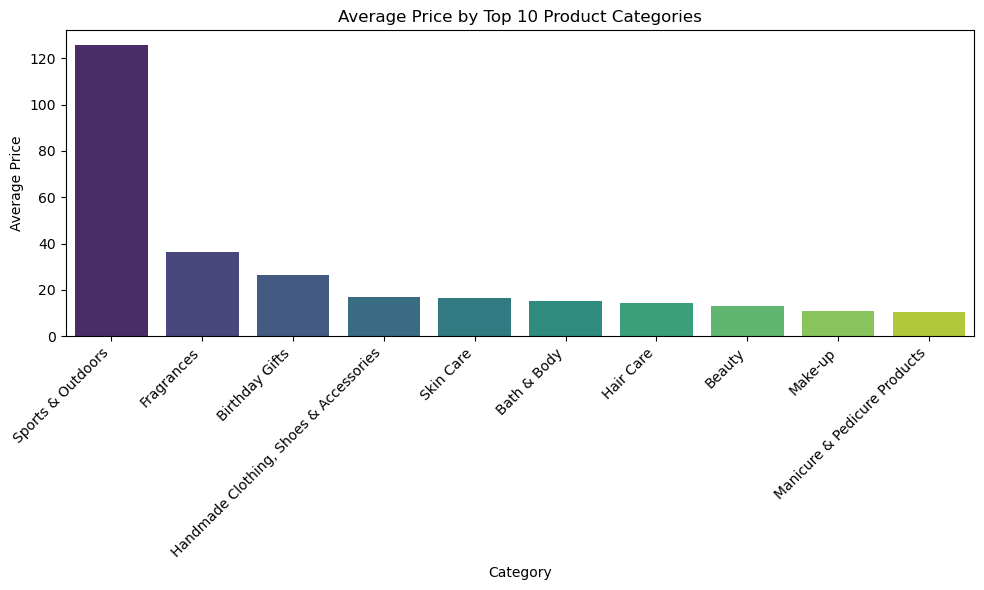

In [64]:
# - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).

# Top 10 categories by number of products
top10_categories = df['category'].value_counts().nlargest(10).index

# Filter dataset
df_top10 = df[df['category'].isin(top10_categories)]

# Compute average price per category
avg_price_top10 = df_top10.groupby('category')['price'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x=avg_price_top10.index,
    y=avg_price_top10.values,
    palette="viridis"
)

plt.xticks(rotation=45, ha='right')
plt.title('Average Price by Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()

In [ ]:
#NOTE: To get only counts (numbers) without lables 
# top10_categories = df['category'].value_counts().nlargest(10).values

array([836265,  19312,  19229,  19092,  18978,  18940,  18769,  18756,
        18735,  18564])

In [49]:
# - Which product category commands the highest average price? Don't filter here by top categories.
# Average price per category
avg_prices = df.groupby('category')['price'].mean()

# Highest average
top_category = avg_prices.idxmax()
top_value = avg_prices.max()

print("Category with highest average price:", top_category)
print("Average price:", top_value)

Category with highest average price: Laptops
Average price: 1087.987826986755


In [50]:
df['category'].value_counts().loc[top_category]

np.int64(7248)

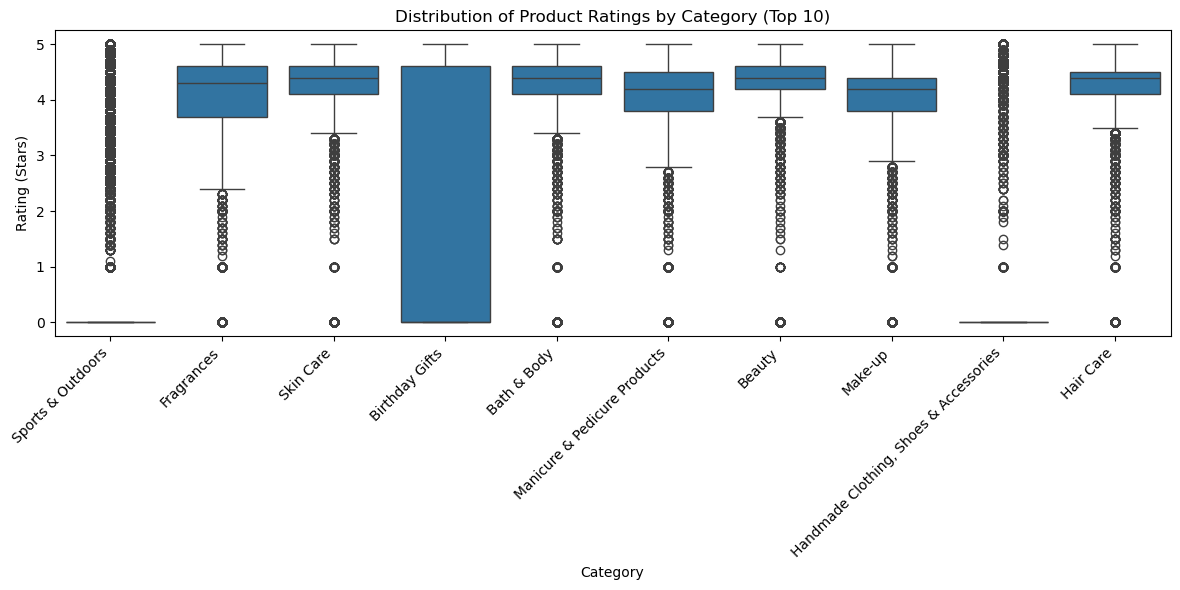

In [69]:
# Visualize the distribution of product ratings based on their category using side-by-side box plots. 
# Filter out the top 10 categories based on count for better visualization.
# Top 10 categories
top10_categories = df['category'].value_counts().nlargest(10).index
df_top10 = df[df['category'].isin(top10_categories)]

# Plot
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_top10,
    x='category',
    y='stars'
)

plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Product Ratings by Category (Top 10)')
plt.xlabel('Category')
plt.ylabel('Rating (Stars)')

plt.tight_layout()
plt.show()

In [75]:
# Which category tends to receive the highest median rating from customers? Don't filter here by top categories.
highest_median_rating = df.groupby("category")["stars"].median()

top_category = highest_median_rating.idxmax()
top_value = highest_median_rating.max()

print("Category with highest median rating:", top_category)
print("Median rating:", top_value)

Category with highest median rating: Computer Memory
Median rating: 4.7


### **Part 3:** Investigating the Interplay Between Product Prices and Ratings
Objective: Analyze how product ratings (stars) correlate with product prices.

**Correlation Coefficients:**

- Calculate the correlation coefficient between price and stars.
- Is there a significant correlation between product price and its rating?

**Visualizations:**

- Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
- Use a correlation heatmap to visualize correlations between all numerical variables.
- Examine if product prices typically follow a normal distribution using a QQ plot.


In [76]:
# Calculating the Pearson correlation coefficient between 'price' and 'stars' columns
correlation = df["price"].corr(df["stars"])
correlation


np.float64(-0.1249067326214861)

In [77]:
# Calculating the Spearman rank correlation between 'price' and 'stars' 
correlation = df["price"].corr(df["stars"], method='spearman')
correlation

np.float64(-0.1331642546243379)

- **Pearson Correlation**: \(-0.12\)
- **Spearman Correlation**: \(-0.13\)

###### The Pearson (r = −0.12) and Spearman (ρ = −0.13) correlations indicate a weak negative relationship between the variables. This suggests that as one variable increases, the other tends to decrease slightly; however, the association is very weak and likely not practically significant.

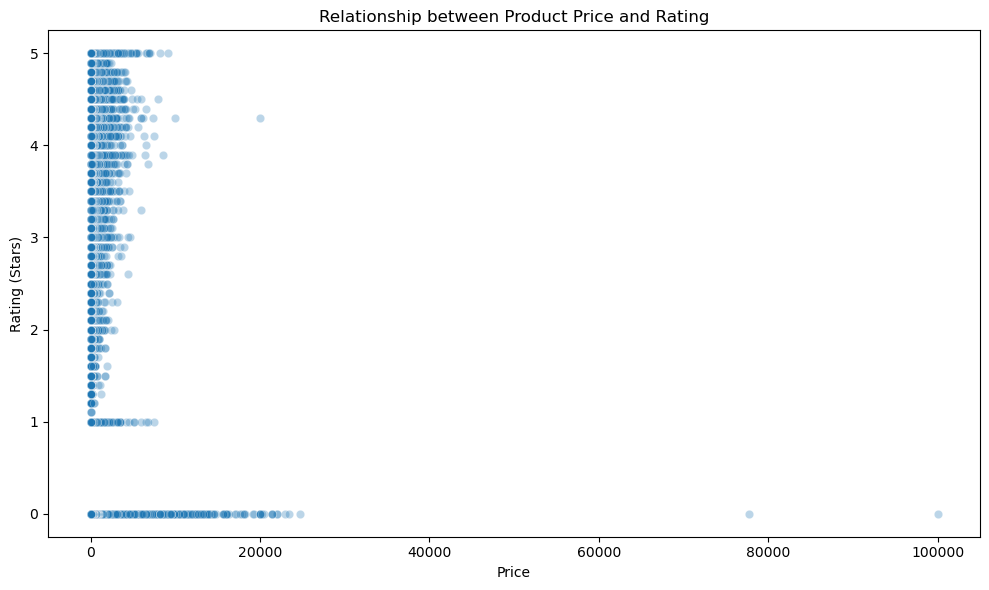

In [78]:
#Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='price',
    y='stars',
    alpha=0.3  # helps with dense data
)

plt.title('Relationship between Product Price and Rating')
plt.xlabel('Price')
plt.ylabel('Rating (Stars)')

plt.tight_layout()
plt.show()

In [ ]:
#Insights
#The scatter plot between product price and rating shows a weak relationship, with points widely dispersed and no clear linear pattern. 
# This aligns with the low correlation values observed earlier, suggesting that price is not a strong predictor of customer ratings.

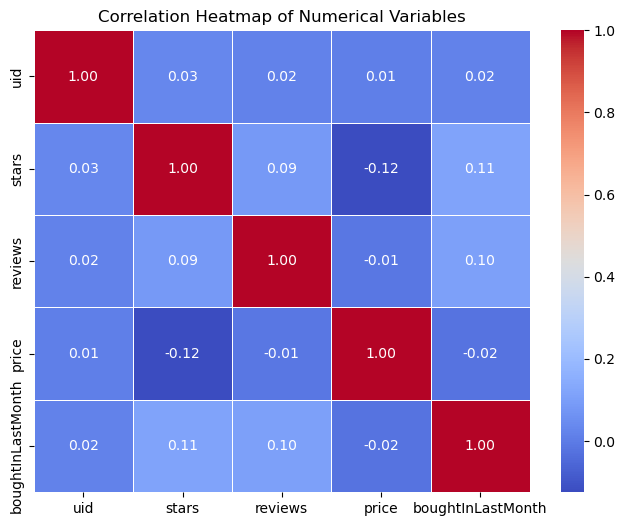

In [81]:
#Use a correlation heatmap to visualize correlations between all numerical variables.
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,        # show values inside cells
    cmap='coolwarm',   # color style
    fmt=".2f",         # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [ ]:
# Correlation values range from -1 to 1:
# A value close to 1 implies a strong positive correlation.
# A value close to -1 implies a strong negative correlation.
# A value close to 0 implies little to no linear/monotonic correlation.

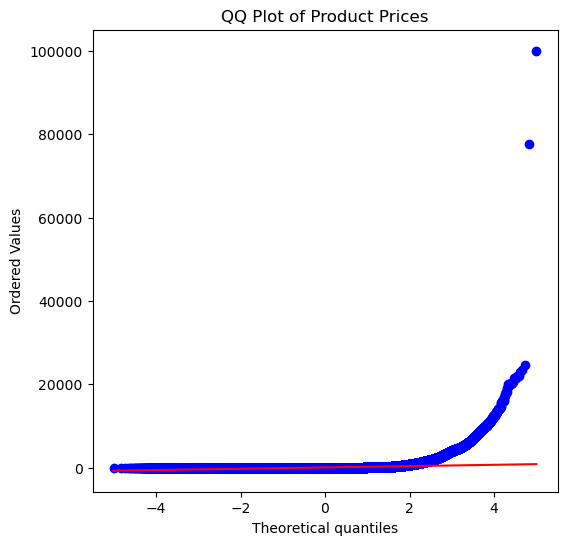

In [82]:
#Examine if product prices typically follow a normal distribution using a QQ plot.
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

stats.probplot(df['price'], dist="norm", plot=plt)

plt.title("QQ Plot of Product Prices")
plt.show()

In [ ]:
#The QQ plot shows that product prices are not normally distributed. The distribution is strongly right-skewed, 
#with most values concentrated at lower prices and a long tail of high-priced outliers. 
#This indicates the presence of extreme values.